In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.ndimage import gaussian_filter1d

from scipy import stats
import statsmodels.formula.api as smf
import scipy.signal as sig
import quantities as pq

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

#for the animation plot video at the very bottom!
import matplotlib.animation as ani

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

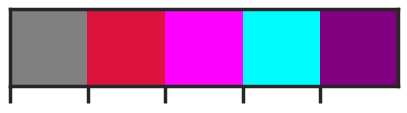

In [3]:
pal=sns.blend_palette(['gray','crimson','magenta','cyan','purple'],5)
sns.palplot(pal)
sns.set_palette(pal)

# Load some necessary variables

In [4]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [5]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

# First, load in the .npy arrays and CC_ls
These were creaded and saved using the "1_saving_LFP_arrays" jupyter notebook

In [6]:
all_rew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_rew.npy")
all_rew2_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_rew2.npy")
all_unrew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_unrew.npy")
all_novel_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\novel_all_rew.npy")

In [7]:
pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_cc_ls"

open_file = open(pkl_file, "rb")
CC_ls = pickle.load(open_file)
open_file.close()

len(CC_ls)

18

In [8]:
nov_pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\novel_cc_ls"

open_file = open(nov_pkl_file, "rb")
nov_CC_ls = pickle.load(open_file)
open_file.close()

len(nov_CC_ls)

16

In [9]:
print('rew: {0}'.format(all_rew_arr.shape))
print('rew2: {0}'.format(all_rew2_arr.shape))
print('unrew: {0}'.format(all_unrew_arr.shape))
print('novel: {0}'.format(all_novel_arr.shape))

rew: (18, 384, 7350)
rew2: (18, 384, 7350)
unrew: (18, 384, 7350)
novel: (16, 384, 7350)


---

# Time Frequency plots
### First, make some functions

In [10]:
def V1HPC(data_array, CC_ls):
    wt = []
    fx = []
    for i in range(data_array.shape[0]):
        if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
            wt.append(data_array[i])
        elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
            fx.append(data_array[i])
    wt_arr = np.array(wt)
    fx_arr = np.array(fx)
    return wt_arr, fx_arr

def find_vep_ch(mouse):
    v1_chs = mouse[200:300,:]
    min_ch = np.where(v1_chs == np.amin(v1_chs))
    min_ch2 = min_ch[0][0] + 199
    return min_ch2

In [11]:
def theta_gamma_filtering(situation_array, hpc_ch1, hpc_ch2):
    allmice_hpc_ch1 = []
    allmice_hpc_ch2 = []
    for idx, mouse in enumerate(situation_array):
        #HPC lfp traces
        hpc_avg_ch1 = mouse[hpc_ch1,:]
        hpc_avg_ch2 = mouse[hpc_ch2,:]
        allmice_hpc_ch1.append(hpc_avg_ch1)
        allmice_hpc_ch2.append(hpc_avg_ch2)
    allmice_hpc_ch1 = np.array(allmice_hpc_ch1)
    allmice_hpc_ch2 = np.array(allmice_hpc_ch2)
    return allmice_hpc_ch1, allmice_hpc_ch2

In [12]:
rew_wt, rew_fx = V1HPC(all_rew_arr, CC_ls)
rew2_wt, rew2_fx = V1HPC(all_rew2_arr, CC_ls)
unrew_wt, unrew_fx = V1HPC(all_unrew_arr, CC_ls)
novel_wt, novel_fx = V1HPC(all_novel_arr, nov_CC_ls)

In [30]:
hpc_ch1 = 180 #140, 100
hpc_ch2 = 150 #110, 120

fs=2500
order=6
lowcutoff = 4
highcutoff = 8
lowcutoff2 = 30
highcutoff2 = 80

In [31]:
#rew
wt_rew_hpc1, wt_rew_hpc2 = theta_gamma_filtering(rew_wt, hpc_ch1, hpc_ch2)
fx_rew_hpc1, fx_rew_hpc2 = theta_gamma_filtering(rew_fx, hpc_ch1, hpc_ch2)

#rew2
wt_rew2_hpc1, wt_rew2_hpc2 = theta_gamma_filtering(rew2_wt, hpc_ch1, hpc_ch2)
fx_rew2_hpc1, fx_rew2_hpc2 = theta_gamma_filtering(rew2_fx, hpc_ch1, hpc_ch2)

#unrew
wt_unrew_hpc1, wt_unrew_hpc2 = theta_gamma_filtering(unrew_wt, hpc_ch1, hpc_ch2)
fx_unrew_hpc1, fx_unrew_hpc2 = theta_gamma_filtering(unrew_fx, hpc_ch1, hpc_ch2)

#novel
wt_novel_hpc1, wt_novel_hpc2 = theta_gamma_filtering(novel_wt, hpc_ch1, hpc_ch2)
fx_novel_hpc1, fx_novel_hpc2 = theta_gamma_filtering(novel_fx, hpc_ch1, hpc_ch2)

In [32]:
def make_tf_data(wt_group_arr, fx_group_arr):
    wt_foo = wt_group_arr.mean(axis=0)
    fx_foo = fx_group_arr.mean(axis=0)
    wt_array = np.reshape(wt_foo,(1,len(wt_foo)))
    fx_array = np.reshape(fx_foo,(1,len(fx_foo)))
    return wt_array, fx_array

In [33]:
#taking the mean of each group/channel for the lineplots
wt_rew_hpc1_mean, fx_rew_hpc1_mean = make_tf_data(wt_rew_hpc1, fx_rew_hpc1)
wt_rew_hpc2_mean, fx_rew_hpc2_mean = make_tf_data(wt_rew_hpc2, fx_rew_hpc2)

wt_rew2_hpc1_mean, fx_rew2_hpc1_mean = make_tf_data(wt_rew2_hpc1, fx_rew2_hpc1)
wt_rew2_hpc2_mean, fx_rew2_hpc2_mean = make_tf_data(wt_rew2_hpc2, fx_rew2_hpc2)

wt_unrew_hpc1_mean, fx_unrew_hpc1_mean = make_tf_data(wt_unrew_hpc1, fx_unrew_hpc1)
wt_unrew_hpc2_mean, fx_unrew_hpc2_mean = make_tf_data(wt_unrew_hpc2, fx_unrew_hpc2)

wt_novel_hpc1_mean, fx_novel_hpc1_mean = make_tf_data(wt_novel_hpc1, fx_novel_hpc1)
wt_novel_hpc2_mean, fx_novel_hpc2_mean = make_tf_data(wt_novel_hpc2, fx_novel_hpc2)

### Fourth, plot the individual TF heatmaps for each group
The cell below requires a _`user input`_ for the scenario you want to look at!

In [34]:
rew_selection = 'rew' #rew, rew2, unrew, novel

if rew_selection == 'rew':
    wt_ch2_plot = wt_rew_hpc2_mean
    fx_ch2_plot = fx_rew_hpc2_mean
    plt_titlewt = 'WT - rew'
    plt_titlefx = 'FX - rew'
    fnwtfx = "rew_wtfx_heat.pdf"
elif rew_selection == 'rew2':
    wt_ch2_plot = wt_rew2_hpc2_mean
    fx_ch2_plot = fx_rew2_hpc2_mean
    plt_titlewt = 'WT - rew2'
    plt_titlefx = 'FX - rew2'
    fnwtfx = "rew2_wtfx_heat.pdf"
elif rew_selection == 'unrew':
    wt_ch2_plot = wt_unrew_hpc2_mean
    fx_ch2_plot = fx_unrew_hpc2_mean
    plt_titlewt = 'WT - unrew'
    plt_titlefx = 'FX - unrew'
    fnwtfx = "unrew_wtfx_heat.pdf"
elif rew_selection == 'novel':
    wt_ch2_plot = wt_novel_hpc2_mean
    fx_ch2_plot = fx_novel_hpc2_mean
    plt_titlewt = 'WT - novel'
    plt_titlefx = 'FX - novel'
    fnwtfx = "novel_wtfx_heat.pdf"
else:
    raise Exception('Input is not one of the options')

C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: divide by zero encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: divide by zero encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temp

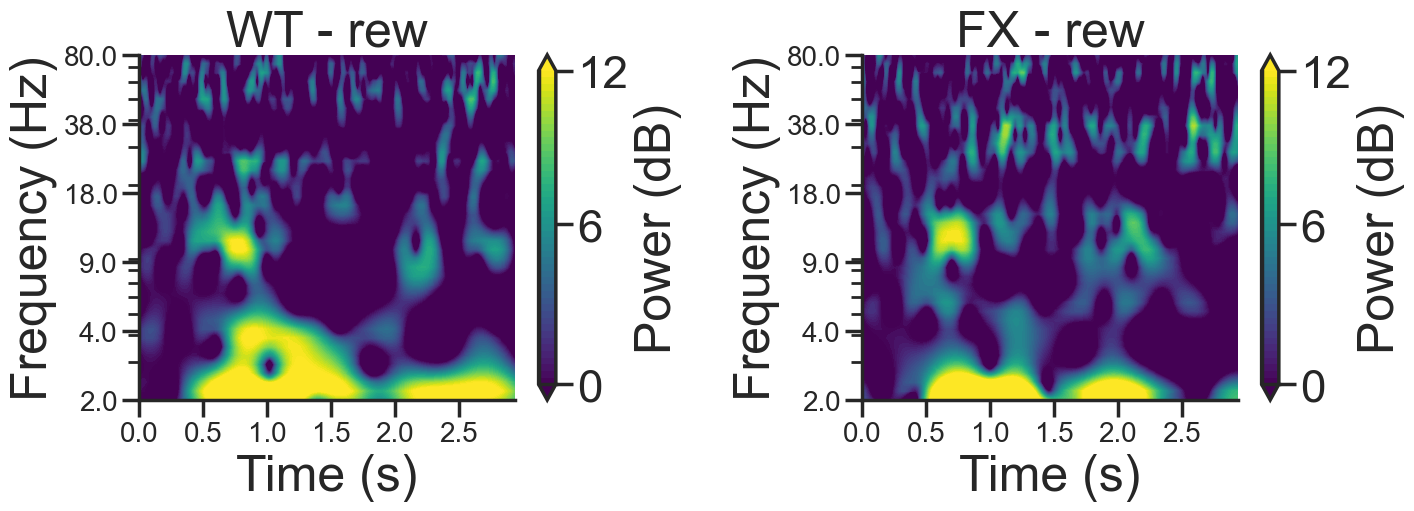

In [36]:
f, (ax1,ax2) = plt.subplots(1,2, figsize=(15,6))

# tf_ch1_wt, time_ch1_wt, frex_ch1_wt, tf3d_ch1_wt = mz_LFP.tf_cmw(ax=ax1, df_res=wt_ch1_plot)
# tf_ch1_fx, time_ch1_fx, frex_ch1_fx, tf3d_ch1_fx = mz_LFP.tf_cmw(ax=ax2, df_res=fx_ch1_plot)
tf_ch2_wt, time_ch2_wt, frex_ch2_wt, tf3d_ch2_wt = mz_LFP.tf_cmw(ax=ax1, df_res=wt_ch2_plot)
tf_ch2_fx, time_ch2_fx, frex_ch2_fx, tf3d_ch2_fx = mz_LFP.tf_cmw(ax=ax2, df_res=fx_ch2_plot)

ax1.set_title(plt_titlewt)
ax2.set_title(plt_titlefx)

sns.despine()
plt.tight_layout()

# Change the end of this next line with a new file name!!
# out_path = r"C:\Users\AChub_Lab\Desktop\hpc_tf_rew.pdf" 
# plt.savefig(out_path, transparent=True)

plt.show()

### Fifth, rerun the TF code to extract the freq. band values
I have to rerun it on each mouse to get the confidence intervals

In [37]:
in_channel = 'ch2' #input('HPC Channel (ch1 or ch2): ')

time_window = [0.7,1.5]

if in_channel == 'ch1':
    wt_rew_df = mz_LFP.TF_band_values(wt_rew_hpc1, time_window)
    fx_rew_df = mz_LFP.TF_band_values(fx_rew_hpc1, time_window)
    wt_rew2_df = mz_LFP.TF_band_values(wt_rew2_hpc1, time_window)
    fx_rew2_df = mz_LFP.TF_band_values(fx_rew2_hpc1, time_window)
    wt_unrew_df = mz_LFP.TF_band_values(wt_unrew_hpc1, time_window)
    fx_unrew_df = mz_LFP.TF_band_values(fx_unrew_hpc1, time_window)
    wt_novel_df = mz_LFP.TF_band_values(wt_novel_hpc1, time_window)
    fx_novel_df = mz_LFP.TF_band_values(fx_novel_hpc1, time_window)
elif in_channel == 'ch2':
    wt_rew_df = mz_LFP.TF_band_values(wt_rew_hpc2, time_window)
    fx_rew_df = mz_LFP.TF_band_values(fx_rew_hpc2, time_window)
    wt_rew2_df = mz_LFP.TF_band_values(wt_rew2_hpc2, time_window)
    fx_rew2_df = mz_LFP.TF_band_values(fx_rew2_hpc2, time_window)
    wt_unrew_df = mz_LFP.TF_band_values(wt_unrew_hpc2, time_window)
    fx_unrew_df = mz_LFP.TF_band_values(fx_unrew_hpc2, time_window)
    wt_novel_df = mz_LFP.TF_band_values(wt_novel_hpc2, time_window)
    fx_novel_df = mz_LFP.TF_band_values(fx_novel_hpc2, time_window)

0


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: divide by zero encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


1


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: divide by zero encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


2


...

C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: divide by zero encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


4


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: divide by zero encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


5


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: divide by zero encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )
C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\LFP\mz_LFP\V1_HPC\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


### Sixth, combine the two group dfs, maintaining an ID for each group

In [38]:
wt_rew_df['group'] = 'WT'
wt_rew_df['stim_id'] = 'Go+'
fx_rew_df['group'] = 'FX'
fx_rew_df['stim_id'] = 'Go+'

wt_rew2_df['group'] = 'WT'
wt_rew2_df['stim_id'] = 'Go-'
fx_rew2_df['group'] = 'FX'
fx_rew2_df['stim_id'] = 'Go-'

wt_unrew_df['group'] = 'WT'
wt_unrew_df['stim_id'] = 'No-Go'
fx_unrew_df['group'] = 'FX'
fx_unrew_df['stim_id'] = 'No-Go'

wt_novel_df['group'] = 'WT'
wt_novel_df['stim_id'] = 'Novel'
fx_novel_df['group'] = 'FX'
fx_novel_df['stim_id'] = 'Novel'

overall_tf = pd.concat([wt_rew_df, fx_rew_df, wt_rew2_df, fx_rew2_df, wt_unrew_df, fx_unrew_df, wt_novel_df, fx_novel_df])
overall_tf.head()

,id,variable,value,dB,group,stim_id
2,0,12-30Hz,6.697687,8.259248,WT,Go+
4,0,30-40Hz,3.681232,5.659931,WT,Go+
3,0,30-70Hz,3.126169,4.950124,WT,Go+
0,0,4-8Hz,2.943995,4.689371,WT,Go+
5,0,50-70Hz,1.460917,1.646255,WT,Go+


In [39]:
print(overall_tf.group.unique())
print(overall_tf.stim_id.unique())

['WT' 'FX']
['Go+' 'Go-' 'No-Go' 'Novel']


### Seventh, plot the frequency band values
separated out from each other by the different groups

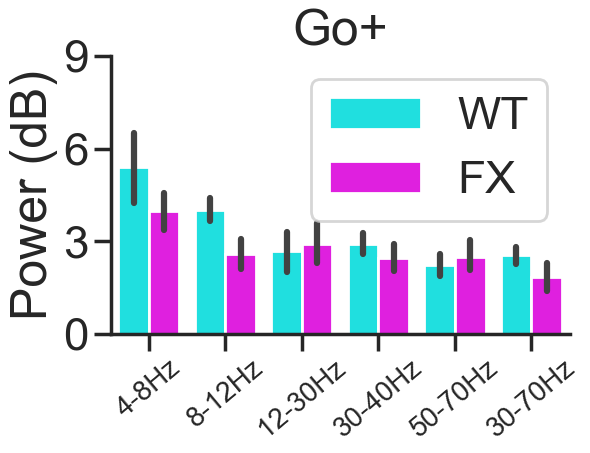

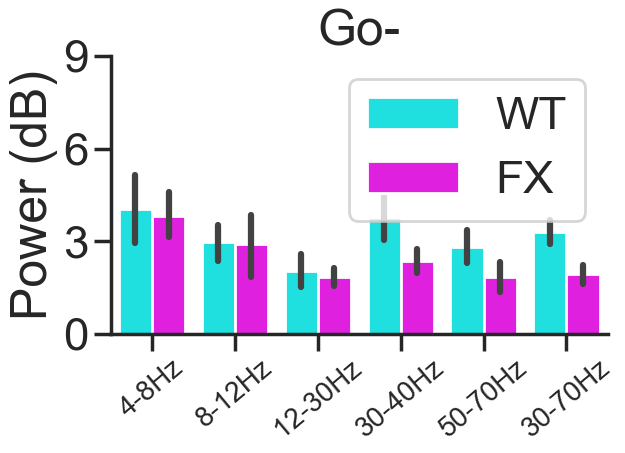

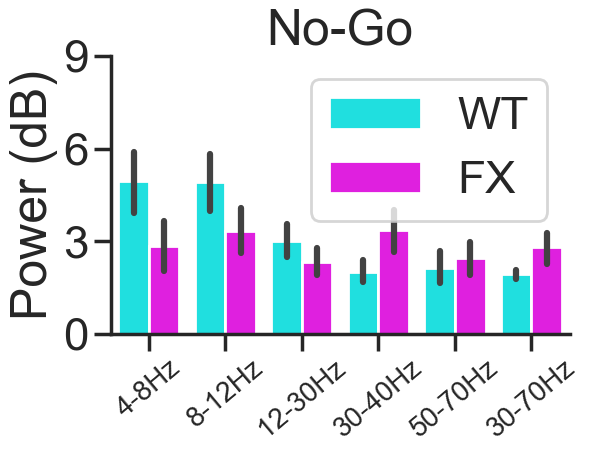

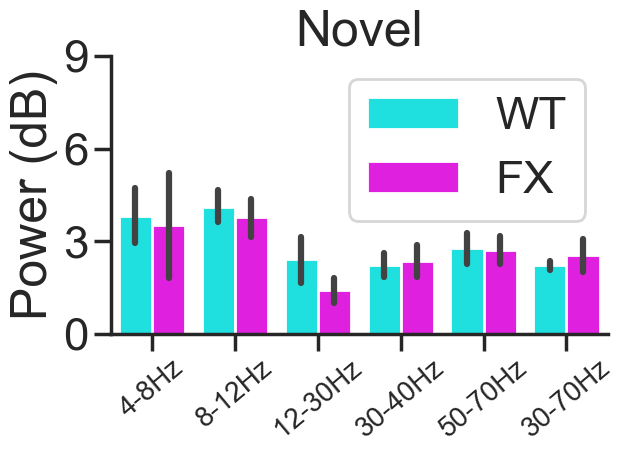

In [40]:
# Plotting the barplot of the T-F plot separated by group

situation_ls = ['Go+', 'Go-', 'No-Go', 'Novel']

for situation in situation_ls:
    TF_plot = overall_tf[overall_tf['stim_id'] == situation]
    plt_title = situation
    
    g = sns.catplot(x='variable', y='value', data=TF_plot, kind = 'bar', 
                    hue='group', hue_order=['WT','FX'], palette=sns.color_palette(['cyan', 'magenta']),
                    legend=False,
                    height = 5, aspect=1.5,
                    order=['4-8Hz', '8-12Hz', '12-30Hz', '30-40Hz','50-70Hz','30-70Hz'], 
                    errorbar=('ci', 68))
    g.set_xticklabels(['4-8Hz', '8-12Hz', '12-30Hz', '30-40Hz','50-70Hz','30-70Hz'], rotation=40, fontsize=20)
    plt.title(plt_title)
    plt.xlabel('')
    plt.yticks([0,3,6,9])
    plt.ylabel('Power (dB)')
    plt.legend(loc="upper right")
    sns.despine()

    # Change the end of this next line with a new file name!!
#     out_path = r"U:\Data\zimmer94\Operant_Reward\V1_HPC\tf" + "\\" + plt_title + "_bar_07-10.pdf"
#     print(out_path)
#     plt.savefig(out_path, transparent=True)

    plt.show()

In [41]:
tf_groups = ['4-8Hz','8-12Hz','12-30Hz','30-40Hz','50-70Hz','30-70Hz']
situation_ls = ['Go+', 'Go-', 'No-Go', 'Novel']

for situation in situation_ls:
    TF_plot = overall_tf[overall_tf['stim_id'] == situation]
    plt_title = situation

    stat_result = []
    for band in tf_groups:
        foo_A = TF_plot[(TF_plot['variable'] == band) & (TF_plot['group'] == 'WT')].value.values
        foo_B = TF_plot[(TF_plot['variable'] == band) & (TF_plot['group'] == 'FX')].value.values
        U, p = stats.mannwhitneyu(foo_A, foo_B)
        stat_result.append(band)
        stat_result.append([U,p])

    print(plt_title)
    print(stat_result)

Go+
['4-8Hz', [47.0, 0.5631715632600889], '8-12Hz', [61.0, 0.06824957172908641], '12-30Hz', [38.0, 0.8938641922116146], '30-40Hz', [48.0, 0.5047202262105325], '50-70Hz', [38.0, 0.8938641922116146], '30-70Hz', [55.0, 0.19715815792857871]]
Go-
['4-8Hz', [36.0, 0.7555690778145971], '8-12Hz', [44.0, 0.7555690778145971], '12-30Hz', [38.0, 0.8938641922116146], '30-40Hz', [54.0, 0.22984963673725034], '50-70Hz', [56.0, 0.16800743830707288], '30-70Hz', [64.0, 0.03660091820858935]]
No-Go
['4-8Hz', [57.0, 0.14221867447100317], '8-12Hz', [52.0, 0.30637501832228387], '12-30Hz', [50.0, 0.39812781090907634], '30-40Hz', [24.0, 0.16800743830707288], '50-70Hz', [33.0, 0.5631715632600889], '30-70Hz', [21.0, 0.09987351755271681]]
Novel
['4-8Hz', [35.0, 0.6249741629567064], '8-12Hz', [35.0, 0.6249741629567064], '12-30Hz', [36.0, 0.5502149953470314], '30-40Hz', [30.0, 1.0], '50-70Hz', [23.0, 0.480148909827134], '30-70Hz', [29.0, 0.956686155113512]]
